In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("IT_Service_Desk_Tickets_50000.csv")

df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              50000 non-null  object 
 1   Ticket_Date            50000 non-null  object 
 2   Customer_ID            50000 non-null  object 
 3   Department             50000 non-null  object 
 4   Agent_Name             50000 non-null  object 
 5   Category               50000 non-null  object 
 6   Sub_Category           50000 non-null  object 
 7   Priority               50000 non-null  object 
 8   Status                 50000 non-null  object 
 9   Resolution_Time_Hours  50000 non-null  float64
 10  SLA_Target_Hours       50000 non-null  int64  
 11  SLA_Status             50000 non-null  object 
 12  Customer_Satisfaction  50000 non-null  float64
 13  Reopened               50000 non-null  object 
 14  Channel                50000 non-null  object 
 15  Ro

,Resolution_Time_Hours,SLA_Target_Hours,Customer_Satisfaction,Year
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,5.872401,8.998800,4.039336,2024.244260
std,6.241298,2.356936,0.635779,0.429652
min,0.210000,4.000000,1.000000,2024.000000
25%,2.110000,8.000000,3.700000,2024.000000
50%,3.740000,8.000000,4.100000,2024.000000
75%,7.200000,12.000000,4.500000,2024.000000
max,72.000000,12.000000,5.000000,2025.000000


In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 50000
Number of Columns: 18


In [4]:
df.columns.tolist()

['Ticket_ID',
 'Ticket_Date',
 'Customer_ID',
 'Department',
 'Agent_Name',
 'Category',
 'Sub_Category',
 'Priority',
 'Status',
 'Resolution_Time_Hours',
 'SLA_Target_Hours',
 'SLA_Status',
 'Customer_Satisfaction',
 'Reopened',
 'Channel',
 'Root_Cause',
 'Month',
 'Year']

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket_ID,50000,50000,TKT048923,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Date,50000,365,2024-07-15,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,50000,5000,CUST03379,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,50000,7,IT,12828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agent_Name,50000,20,Aditya Jain,2562,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,50000,5,Software,13555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub_Category,50000,20,License Issue,3433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Priority,50000,4,Low,20911,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,50000,4,Resolved,38973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Resolution_Time_Hours,50000.0,NaN,NaN,NaN,5.872401,6.241298,0.21,2.11,3.74,7.2,72.0


In [6]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [7]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

Series([], dtype: float64)

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
print("Duplicate Ticket IDs:", df["Ticket_ID"].duplicated().sum())

Duplicate Ticket IDs: 0


In [10]:
df.dtypes

Ticket_ID                 object
Ticket_Date               object
Customer_ID               object
Department                object
Agent_Name                object
Category                  object
Sub_Category              object
Priority                  object
Status                    object
Resolution_Time_Hours    float64
SLA_Target_Hours           int64
SLA_Status                object
Customer_Satisfaction    float64
Reopened                  object
Channel                   object
Root_Cause                object
Month                     object
Year                       int64
dtype: object

In [11]:
df["Ticket_Date"] = pd.to_datetime(df["Ticket_Date"])

df["Ticket_Date"].head()

0   2024-04-01
1   2024-04-01
2   2024-04-01
3   2024-04-01
4   2024-04-01
Name: Ticket_Date, dtype: datetime64[ns]

In [12]:
print("Minimum Date:", df["Ticket_Date"].min())
print("Maximum Date:", df["Ticket_Date"].max())

Minimum Date: 2024-04-01 00:00:00
Maximum Date: 2025-03-31 00:00:00


In [13]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].nunique())


Ticket_ID:
50000

Ticket_Date:
365

Customer_ID:
5000

Department:
7

Agent_Name:
20

Category:
5

Sub_Category:
20

Priority:
4

Status:
4

Resolution_Time_Hours:
3136

SLA_Target_Hours:
3

SLA_Status:
2

Customer_Satisfaction:
41

Reopened:
2

Channel:
4

Root_Cause:
7

Month:
12

Year:
2


In [14]:
status_counts = df["Status"].value_counts()

print(status_counts)

Status
Resolved       38973
In Progress     5100
Open            3931
Pending         1996
Name: count, dtype: int64


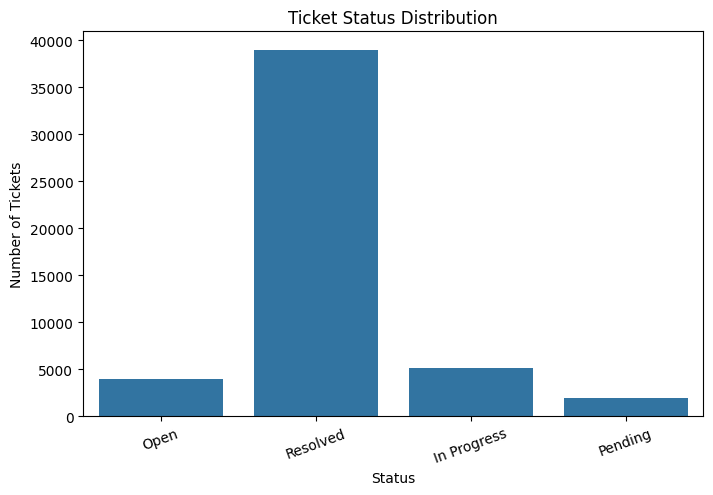

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Status")

plt.title("Ticket Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=20)

plt.show()

In [16]:
priority_counts = df["Priority"].value_counts()

print(priority_counts)

Priority
Low         20911
Medium      16481
High         8612
Critical     3996
Name: count, dtype: int64


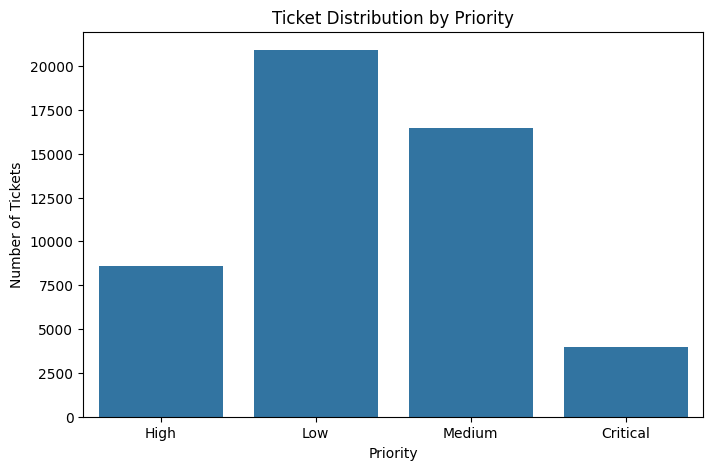

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Priority")

plt.title("Ticket Distribution by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.show()

In [18]:
department_counts = df["Department"].value_counts()

print(department_counts)

Department
IT            12828
Finance        9125
HR             7075
Sales          5839
Operations     5478
Others         5118
Marketing      4537
Name: count, dtype: int64


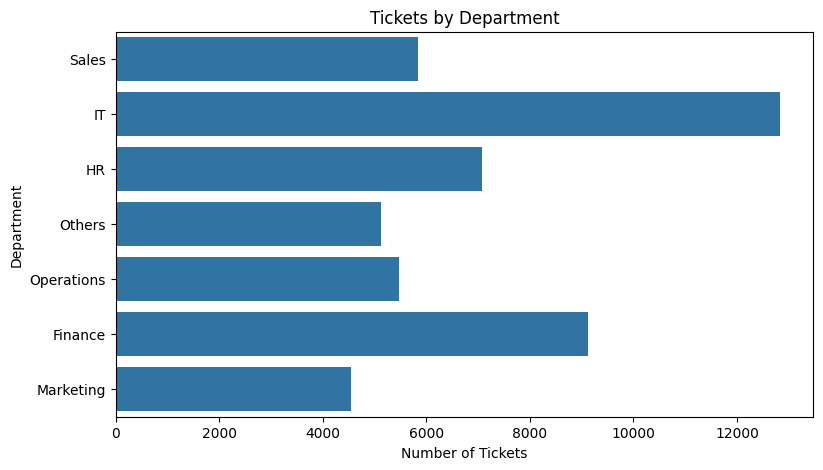

In [19]:
plt.figure(figsize=(9,5))

sns.countplot(data=df, y="Department")

plt.title("Tickets by Department")
plt.xlabel("Number of Tickets")
plt.ylabel("Department")

plt.show()

In [20]:
category_counts = df["Category"].value_counts()

print(category_counts)

Category
Software                13555
Hardware                10424
Application Support      9431
Network                  9144
Access & Permissions     7446
Name: count, dtype: int64


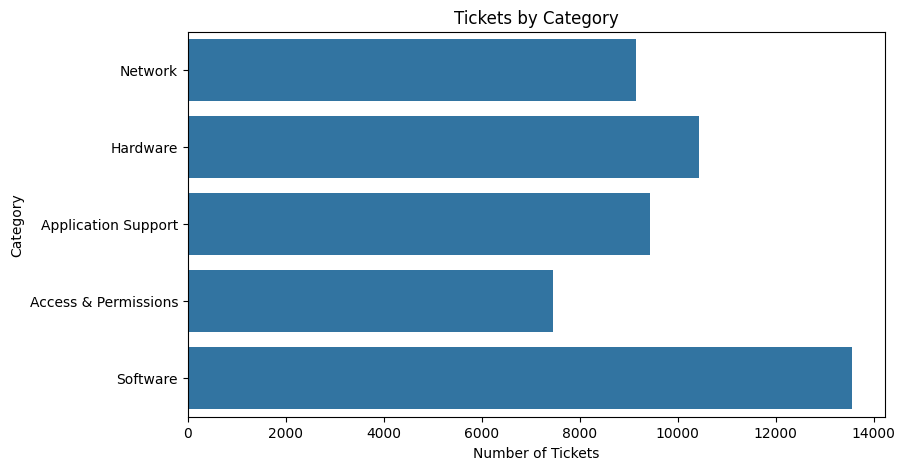

In [21]:
plt.figure(figsize=(9,5))

sns.countplot(data=df, y="Category")

plt.title("Tickets by Category")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")

plt.show()

In [22]:
subcategory_counts = df["Sub_Category"].value_counts()

print(subcategory_counts.head(15))

Sub_Category
License Issue        3433
Installation         3414
Update/Upgrade       3367
Application Error    3341
Printer              2657
Laptop/Desktop       2603
Monitor              2591
Peripheral           2573
Database Support     2373
CRM Support          2367
Email Support        2346
ERP Support          2345
Connectivity         2292
VPN                  2292
Slow Network         2283
Name: count, dtype: int64


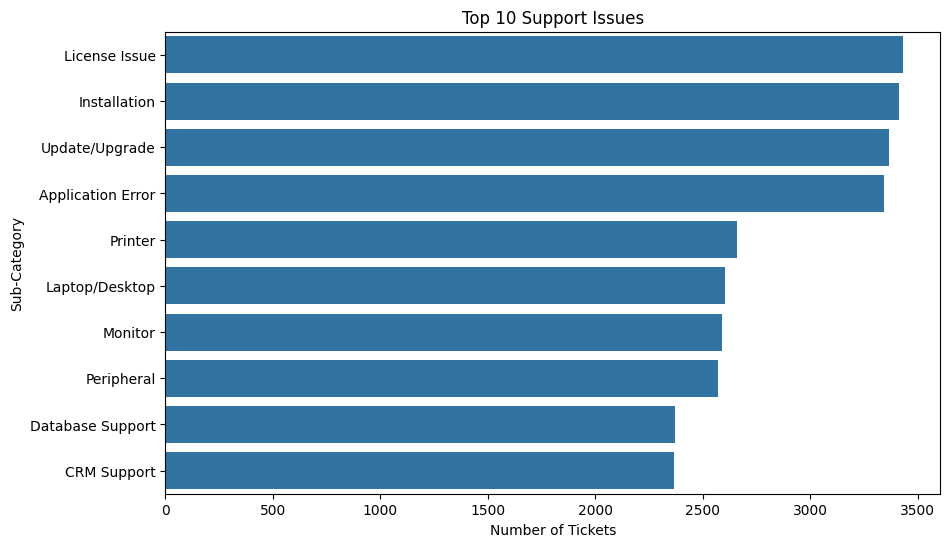

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=subcategory_counts.head(10).values,
    y=subcategory_counts.head(10).index
)

plt.title("Top 10 Support Issues")
plt.xlabel("Number of Tickets")
plt.ylabel("Sub-Category")

plt.show()

In [24]:
channel_counts = df["Channel"].value_counts()

print(channel_counts)

Channel
Portal    17963
Email     16983
Phone      9078
Chat       5976
Name: count, dtype: int64


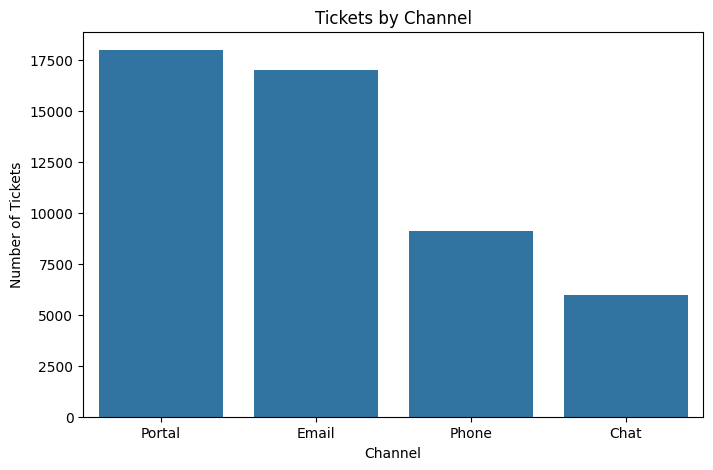

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Channel")

plt.title("Tickets by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Tickets")

plt.show()

In [26]:
sla_counts = df["SLA_Status"].value_counts()

print(sla_counts)

SLA_Status
Met         39675
Breached    10325
Name: count, dtype: int64


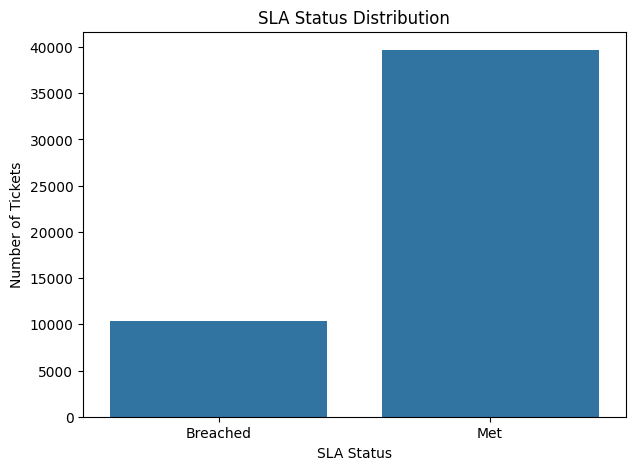

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="SLA_Status")

plt.title("SLA Status Distribution")
plt.xlabel("SLA Status")
plt.ylabel("Number of Tickets")

plt.show()

In [28]:
sla_compliance = (
    (df["SLA_Status"] == "Met").sum()
    / len(df)
) * 100

print(f"SLA Compliance: {sla_compliance:.2f}%")

SLA Compliance: 79.35%


In [29]:
sla_breaches = (
    df[df["SLA_Status"] == "Breached"]
    .groupby("Department")
    .size()
    .sort_values(ascending=False)
)

print(sla_breaches)

Department
IT            2583
Finance       1893
HR            1522
Sales         1207
Operations    1147
Others        1058
Marketing      915
dtype: int64


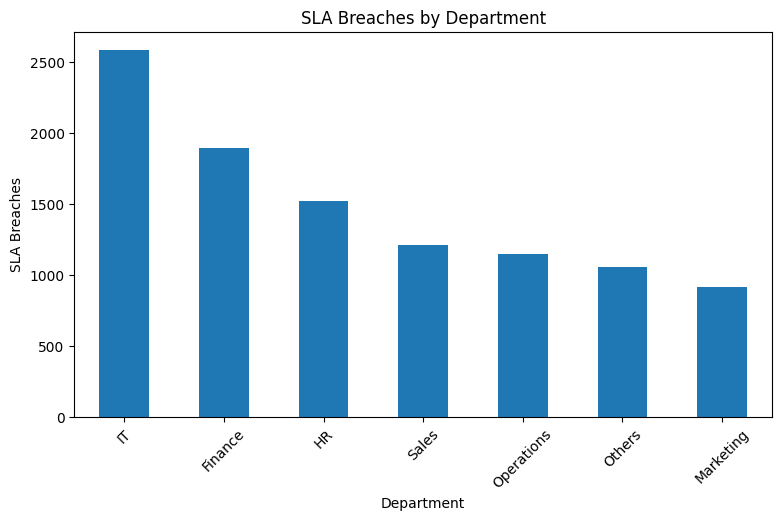

In [30]:
plt.figure(figsize=(9,5))

sla_breaches.plot(kind="bar")

plt.title("SLA Breaches by Department")
plt.xlabel("Department")
plt.ylabel("SLA Breaches")
plt.xticks(rotation=45)

plt.show()

In [31]:
print("Average Resolution Time:",
      round(df["Resolution_Time_Hours"].mean(), 2), "hours")

print("Median Resolution Time:",
      round(df["Resolution_Time_Hours"].median(), 2), "hours")

print("Maximum Resolution Time:",
      round(df["Resolution_Time_Hours"].max(), 2), "hours")

Average Resolution Time: 5.87 hours
Median Resolution Time: 3.74 hours
Maximum Resolution Time: 72.0 hours


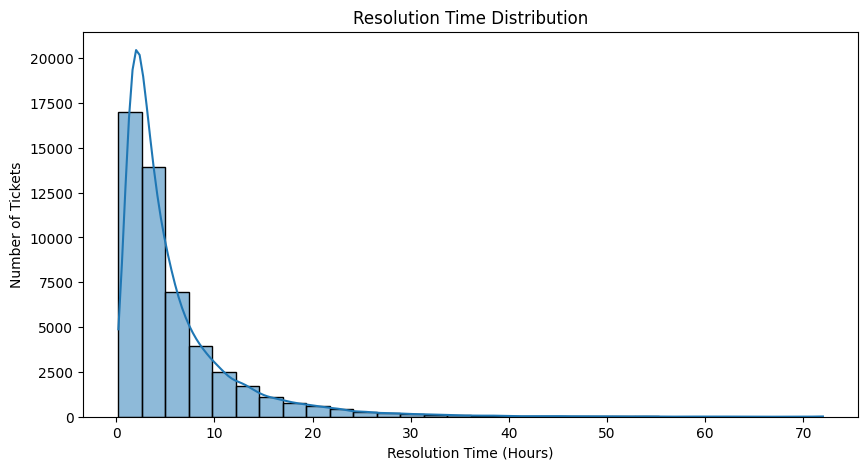

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Resolution_Time_Hours"],
    bins=30,
    kde=True
)

plt.title("Resolution Time Distribution")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Number of Tickets")

plt.show()

In [33]:
avg_resolution_priority = (
    df.groupby("Priority")["Resolution_Time_Hours"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_resolution_priority)

Priority
Critical    17.802993
High        10.236011
Medium       5.152912
Low          2.362470
Name: Resolution_Time_Hours, dtype: float64


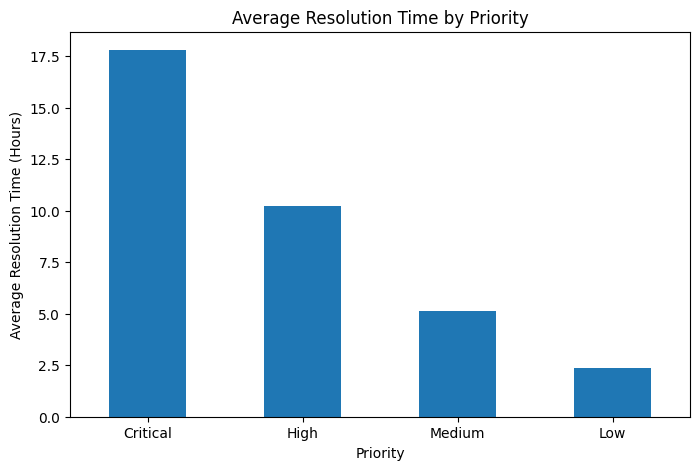

In [34]:
plt.figure(figsize=(8,5))

avg_resolution_priority.plot(kind="bar")

plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Time (Hours)")
plt.xticks(rotation=0)

plt.show()

In [35]:
print("Average Customer Satisfaction:",
      round(df["Customer_Satisfaction"].mean(), 2))

Average Customer Satisfaction: 4.04


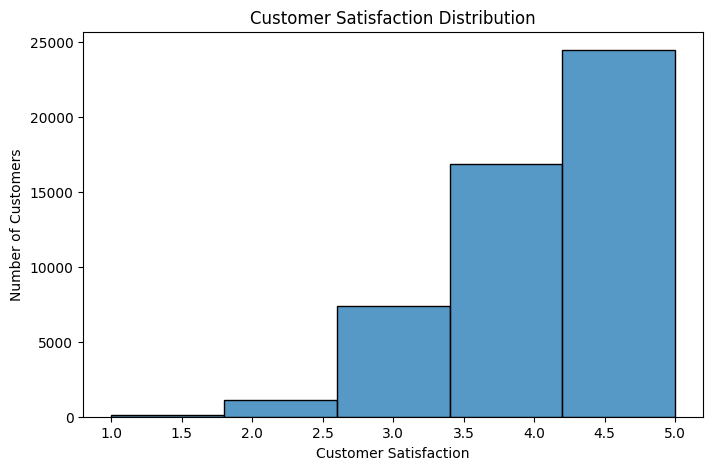

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Customer_Satisfaction"],
    bins=5
)

plt.title("Customer Satisfaction Distribution")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Number of Customers")

plt.show()

In [37]:
satisfaction_department = (
    df.groupby("Department")["Customer_Satisfaction"]
    .mean()
    .sort_values(ascending=False)
)

print(satisfaction_department)

Department
Sales         4.048724
IT            4.046960
Marketing     4.042473
HR            4.041131
Finance       4.034334
Others        4.030344
Operations    4.023293
Name: Customer_Satisfaction, dtype: float64


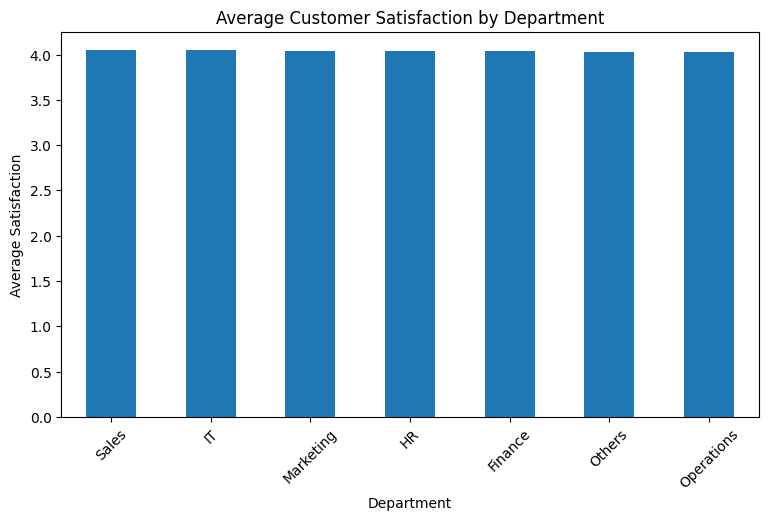

In [38]:
plt.figure(figsize=(9,5))

satisfaction_department.plot(kind="bar")

plt.title("Average Customer Satisfaction by Department")
plt.xlabel("Department")
plt.ylabel("Average Satisfaction")
plt.xticks(rotation=45)

plt.show()

In [39]:
reopened_counts = df["Reopened"].value_counts()

print(reopened_counts)

Reopened
No     47688
Yes     2312
Name: count, dtype: int64


In [40]:
reopened_percentage = (
    (df["Reopened"] == "Yes").sum()
    / len(df)
) * 100

print(f"Reopened Ticket Percentage: {reopened_percentage:.2f}%")

Reopened Ticket Percentage: 4.62%


In [41]:
reopened_category = (
    df[df["Reopened"] == "Yes"]
    .groupby("Category")
    .size()
    .sort_values(ascending=False)
)

print(reopened_category)

Category
Software                629
Hardware                502
Application Support     422
Network                 422
Access & Permissions    337
dtype: int64


In [42]:
root_cause_counts = df["Root_Cause"].value_counts()

print(root_cause_counts)

Root_Cause
Software Bug           10966
User Error             10082
Network Issue           8006
Hardware Failure        6880
Access Issue            6061
Configuration Error     5527
Unknown                 2478
Name: count, dtype: int64


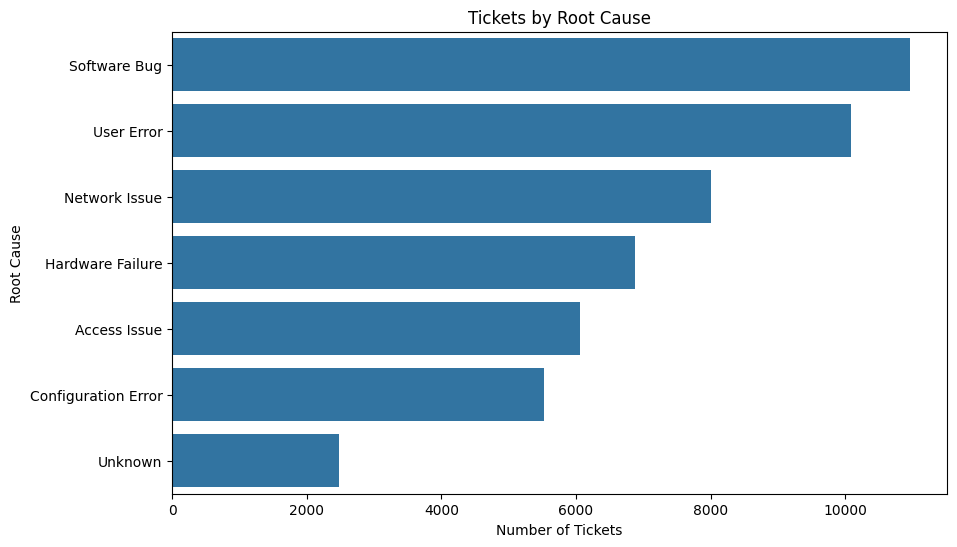

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=root_cause_counts.values,
    y=root_cause_counts.index
)

plt.title("Tickets by Root Cause")
plt.xlabel("Number of Tickets")
plt.ylabel("Root Cause")

plt.show()

In [44]:
monthly_tickets = (
    df.groupby(df["Ticket_Date"].dt.to_period("M"))
    .size()
)

print(monthly_tickets)

Ticket_Date
2024-04    4231
2024-05    4275
2024-06    4165
2024-07    4296
2024-08    4213
2024-09    4061
2024-10    4162
2024-11    4139
2024-12    4245
2025-01    4166
2025-02    3834
2025-03    4213
Freq: M, dtype: int64


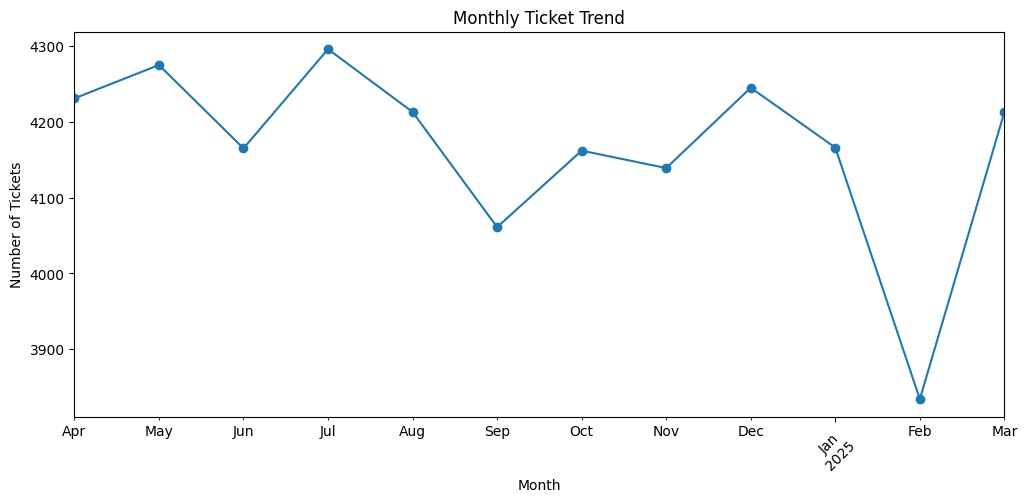

In [45]:
plt.figure(figsize=(12,5))

monthly_tickets.plot(kind="line", marker="o")

plt.title("Monthly Ticket Trend")
plt.xlabel("Month")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)

plt.show()

In [46]:
monthly_sla = (
    df.assign(
        SLA_Met=df["SLA_Status"] == "Met"
    )
    .groupby(df["Ticket_Date"].dt.to_period("M"))["SLA_Met"]
    .mean()
    * 100
)

print(monthly_sla)

Ticket_Date
2024-04    79.721106
2024-05    79.883041
2024-06    79.615846
2024-07    79.934823
2024-08    79.848089
2024-09    80.177296
2024-10    78.207593
2024-11    79.270355
2024-12    79.010601
2025-01    78.636582
2025-02    79.264476
2025-03    78.613814
Freq: M, Name: SLA_Met, dtype: float64


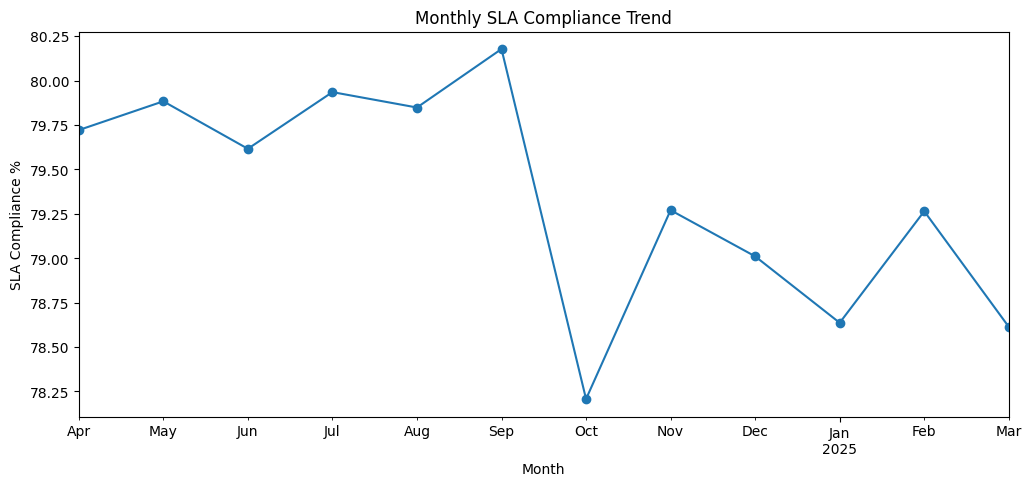

In [47]:
plt.figure(figsize=(12,5))

monthly_sla.plot(kind="line", marker="o")

plt.title("Monthly SLA Compliance Trend")
plt.xlabel("Month")
plt.ylabel("SLA Compliance %")

plt.show()

In [48]:
agent_productivity = (
    df[df["Status"] == "Resolved"]
    .groupby("Agent_Name")
    .size()
    .sort_values(ascending=False)
)

print(agent_productivity)

Agent_Name
Nikhil Patil     2022
Anjali Verma     2013
Neha Gupta       1983
Arjun Shah       1981
Sneha Desai      1975
Aarav Sharma     1975
Vikram Rao       1975
Amit Singh       1973
Aditya Jain      1972
Simran Kaur      1967
Karan Mehta      1950
Meera Iyer       1950
Rohan Kapoor     1938
Saurabh Yadav    1920
Kavya Reddy      1909
Pooja Nair       1904
Priya Patel      1901
Isha Malhotra    1891
Riya Kulkarni    1888
Rahul Joshi      1886
dtype: int64


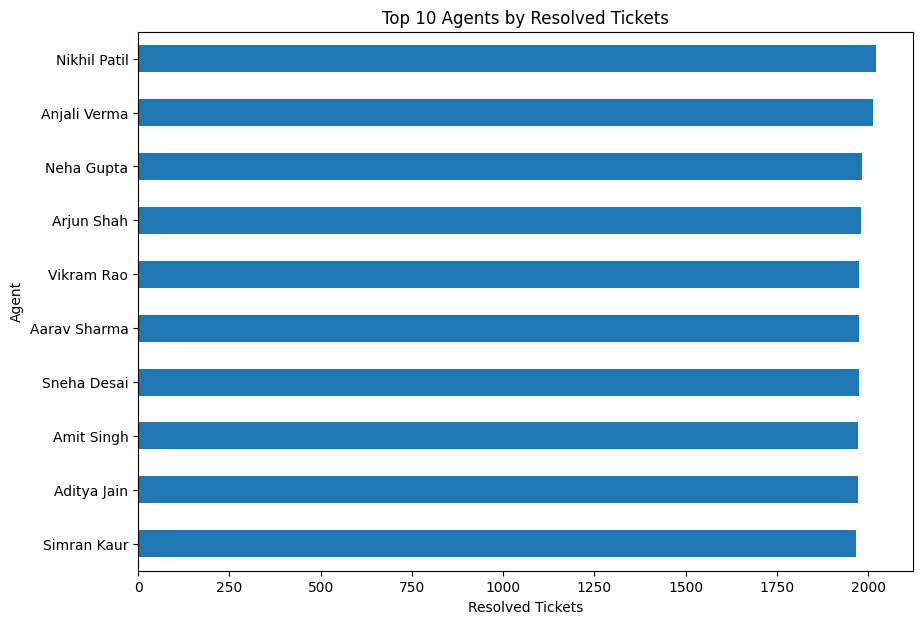

In [49]:
plt.figure(figsize=(10,7))

agent_productivity.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Agents by Resolved Tickets")
plt.xlabel("Resolved Tickets")
plt.ylabel("Agent")

plt.show()

In [50]:
agent_resolution = (
    df.groupby("Agent_Name")["Resolution_Time_Hours"]
    .mean()
    .sort_values()
)

print(agent_resolution)

Agent_Name
Aditya Jain      5.658443
Pooja Nair       5.683325
Nikhil Patil     5.705029
Amit Singh       5.733874
Priya Patel      5.761076
Simran Kaur      5.786361
Isha Malhotra    5.799734
Rohan Kapoor     5.803202
Arjun Shah       5.859015
Saurabh Yadav    5.879528
Vikram Rao       5.885781
Rahul Joshi      5.915845
Anjali Verma     5.915950
Riya Kulkarni    5.954907
Neha Gupta       5.971968
Meera Iyer       5.984771
Sneha Desai      6.020420
Karan Mehta      6.023098
Aarav Sharma     6.046059
Kavya Reddy      6.064016
Name: Resolution_Time_Hours, dtype: float64


In [51]:
department_summary = df.groupby("Department").agg(
    Total_Tickets=("Ticket_ID", "count"),
    Avg_Resolution_Time=("Resolution_Time_Hours", "mean"),
    Avg_Satisfaction=("Customer_Satisfaction", "mean"),
    SLA_Breaches=("SLA_Status", lambda x: (x == "Breached").sum()),
    Reopened_Tickets=("Reopened", lambda x: (x == "Yes").sum())
)

department_summary

,Total_Tickets,Avg_Resolution_Time,Avg_Satisfaction,SLA_Breaches,Reopened_Tickets
Department,,,,,
Finance,9125,6.002568,4.034334,1893,446
HR,7075,5.934035,4.041131,1522,300
IT,12828,5.813211,4.046960,2583,579
Marketing,4537,5.816615,4.042473,915,228
Operations,5478,5.949230,4.023293,1147,256
Others,5118,5.843550,4.030344,1058,230
Sales,5839,5.720891,4.048724,1207,273


In [52]:
priority_sla = pd.crosstab(
    df["Priority"],
    df["SLA_Status"]
)

priority_sla

SLA_Status,Breached,Met
Priority,,
Critical,3855,141
High,4856,3756
Low,634,20277
Medium,980,15501


In [53]:
category_status = pd.crosstab(
    df["Category"],
    df["Status"]
)

category_status

Status,In Progress,Open,Pending,Resolved
Category,,,,
Access & Permissions,760,578,290,5818
Application Support,941,775,370,7345
Hardware,1114,782,435,8093
Network,937,734,339,7134
Software,1348,1062,562,10583


In [54]:
numeric_columns = [
    "Resolution_Time_Hours",
    "SLA_Target_Hours",
    "Customer_Satisfaction"
]

correlation = df[numeric_columns].corr()

correlation

,Resolution_Time_Hours,SLA_Target_Hours,Customer_Satisfaction
Resolution_Time_Hours,1.000000,-0.323765,-0.651739
SLA_Target_Hours,-0.323765,1.000000,0.317419
Customer_Satisfaction,-0.651739,0.317419,1.000000


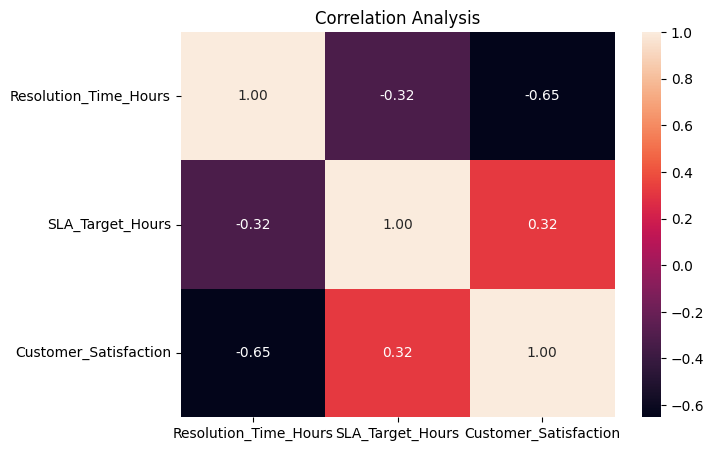

In [55]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Analysis")

plt.show()

In [56]:
print("========== IT SERVICE DESK BUSINESS INSIGHTS ==========\n")

print(
    f"1. Total tickets handled: {len(df):,}"
)

print(
    f"2. SLA compliance: {sla_compliance:.2f}%"
)

print(
    f"3. Average resolution time: "
    f"{df['Resolution_Time_Hours'].mean():.2f} hours"
)

print(
    f"4. Average customer satisfaction: "
    f"{df['Customer_Satisfaction'].mean():.2f}/5"
)

print(
    f"5. Reopened tickets: "
    f"{(df['Reopened'] == 'Yes').sum():,}"
)

print(
    f"6. Most common priority: "
    f"{df['Priority'].mode()[0]}"
)

print(
    f"7. Most common category: "
    f"{df['Category'].mode()[0]}"
)

print(
    f"8. Department with highest ticket volume: "
    f"{df['Department'].value_counts().idxmax()}"
)

print(
    f"9. Most common support channel: "
    f"{df['Channel'].value_counts().idxmax()}"
)

print(
    f"10. Most common root cause: "
    f"{df['Root_Cause'].value_counts().idxmax()}"
)

========== IT SERVICE DESK BUSINESS INSIGHTS ==========

1. Total tickets handled: 50,000
2. SLA compliance: 79.35%
3. Average resolution time: 5.87 hours
4. Average customer satisfaction: 4.04/5
5. Reopened tickets: 2,312
6. Most common priority: Low
7. Most common category: Software
8. Department with highest ticket volume: IT
9. Most common support channel: Portal
10. Most common root cause: Software Bug
